# Evaluate model 2024_11_26_153644

python main.py --gpu 0 --gpu_frac 0.20 --n_trials 8000 --mode train \
--N 200 --P_inh 0.20 --som_N 0 --apply_dale True --gain 1.5 --task letters \
--act sigmoid --loss_fn l2 --decay_taus 4 25 --output_dir ../

- 'T': 300
- 'stim_on': 50 
- 'stim_dur': 100
- 'delay': 10
- 'DeltaT': 1
- 'taus': args.decay_taus 
- 'task': args.task.lower()

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import sys 

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
import model
from model import generate_input_stim_letters


sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import importlib

2024-11-26 15:38:38.544618: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-26 15:38:38.545573: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-26 15:38:38.547880: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-26 15:38:38.554316: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-26 15:38:38.563192: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Instructions for updating:
non-resource variables are not supported in the long term


## Rate model

### load model

In [2]:
model_dir = '/home/nuttidalab/Documents/spikeRNN/models/letters/P_rec_0.2_Taus_4.0_25.0/'
model_fname = 'Task_letters_N_200_Taus_4.0_25.0_Act_sigmoid_2024_11_26_153644'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

### visualize training settings

In [3]:
tr_settings = {
            'T': 300, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 100, # input stim duration (in steps)
            'delay': 10, # delay before probe (in steps)
            'DeltaT': 1, # sampling rate
            'taus': [4, 25], # decay time-constants (in steps)
            'task': 'letters', # task name
            }

In [4]:
print(f'total training trials: {mat_data["tr"]}')

total training trials: [[7999]]


(4, 300)


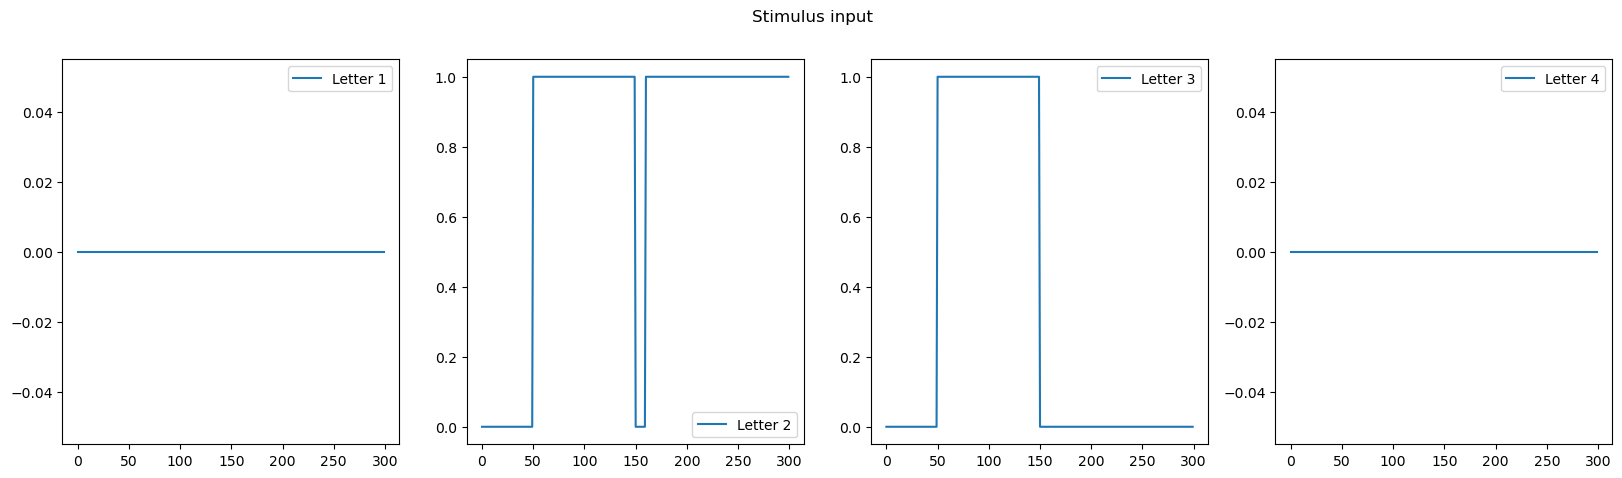

In [5]:
# visualize stim
stim = mat_data['u']
print(stim.shape)
fig, axs = plt.subplots(1, len(stim), figsize=(20, 5))
for i, ax in enumerate(axs):
    ax.plot(stim[i], label=f'Letter {i+1}')
    ax.legend()
plt.suptitle('Stimulus input')
plt.show()

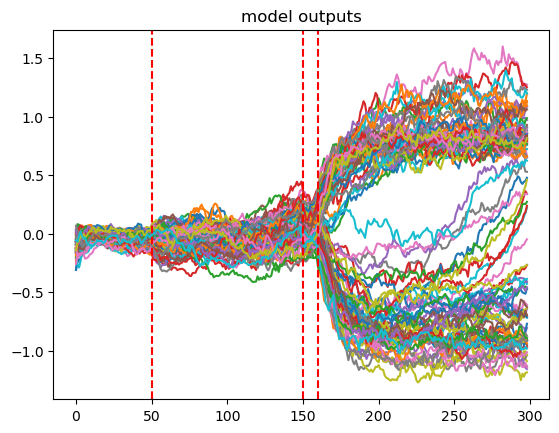

In [6]:
# visualize outputs

plt.figure()
plt.plot(np.transpose(mat_data['eval_os'][:,]))
plt.title('model outputs')
plt.axvline(x=tr_settings['stim_on'], color='r', linestyle='--')
plt.axvline(x=tr_settings['stim_on']+tr_settings['stim_dur'], color='r', linestyle='--')
plt.axvline(x=tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'], color='r', linestyle='--')
plt.show()

In [7]:
# get exc and inh indices

exc = mat_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = mat_data['inh']
inh_ind = np.where(inh == 1)[0]
print(inh_ind)

[ 11  15  17  22  24  25  32  36  37  41  44  52  56  68  69  76  79  84
  87 100 110 115 118 126 131 136 139 142 143 148 163 168 170 174 177 178
 181 185 188 192 198]


### training eval

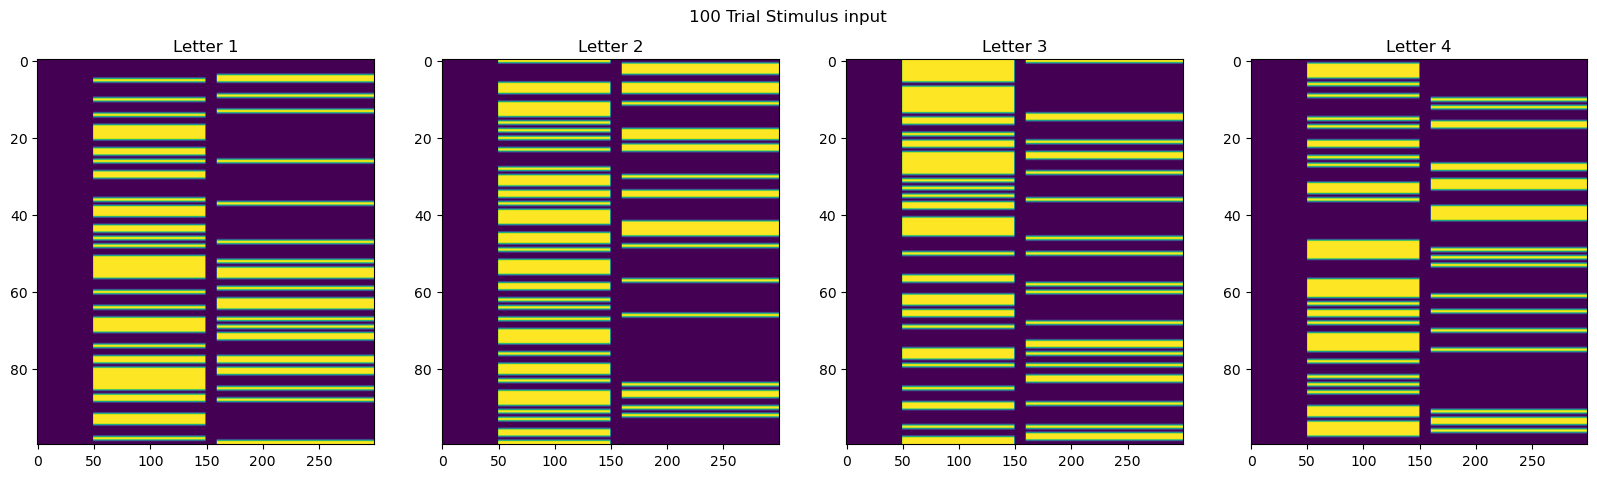

In [8]:
# generate 100 example stim to visualize

stim = np.zeros((100, len(mat_data['u']), tr_settings['T']))
for i in range(100):
    stim[i,:,:], _ = generate_input_stim_letters(tr_settings)

# visualize stim
n_letters = len(mat_data['u'])
fig, axs = plt.subplots(1, n_letters, figsize=(20, 5))
for i, ax in enumerate(axs):
    ax.imshow(stim[:,i,:], aspect='auto')
    ax.set_title(f'Letter {i+1}')
plt.suptitle('100 Trial Stimulus input')
plt.show()

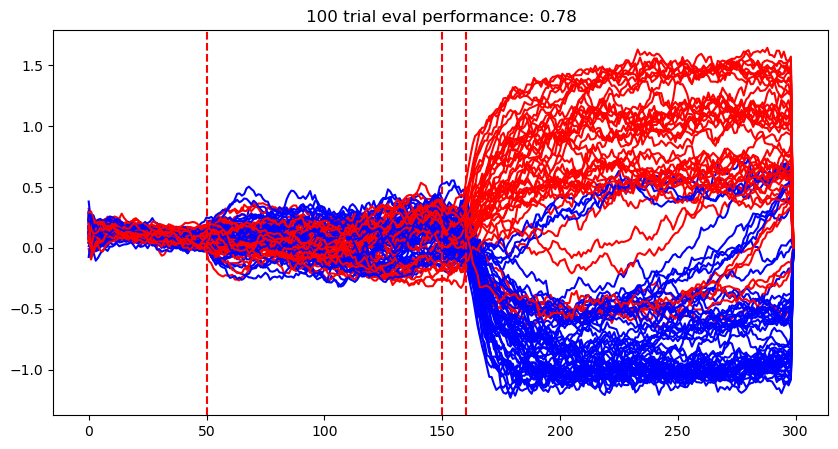

In [10]:
# model eval on 100 trials

n_trials = 100
resp_onset = tr_settings['stim_on'] + tr_settings['stim_dur'] + tr_settings['delay']
eval_amp_threshold = 0.7
eval_perf = np.zeros(n_trials)

plt.figure(figsize=(10, 5))
for i in range(n_trials):
    eval_u, eval_label = generate_input_stim_letters(tr_settings)
    _, _, eval_o = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=tr_settings, u=eval_u)
    if eval_label == 1:
        plt.plot(eval_o, c='r')
        if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
            eval_perf[i] = 1
    else:
        plt.plot(eval_o, c='b')
        if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
            eval_perf[i] = 1

plt.axvline(x=tr_settings['stim_on'], color='r', linestyle='--')
plt.axvline(x=tr_settings['stim_on']+tr_settings['stim_dur'], color='r', linestyle='--')
plt.axvline(x=tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'], color='r', linestyle='--')

eval_perf_mean = np.nanmean(eval_perf)
plt.title("100 trial eval performance: %.2f"%(eval_perf_mean))
plt.show()

### visualize model fr (r) and synaptic current (x)

In [11]:
r = np.squeeze(mat_data['r'])
x = np.squeeze(mat_data['x'])
print(r.shape)
print(x.shape)

(300, 200)
(300, 200)


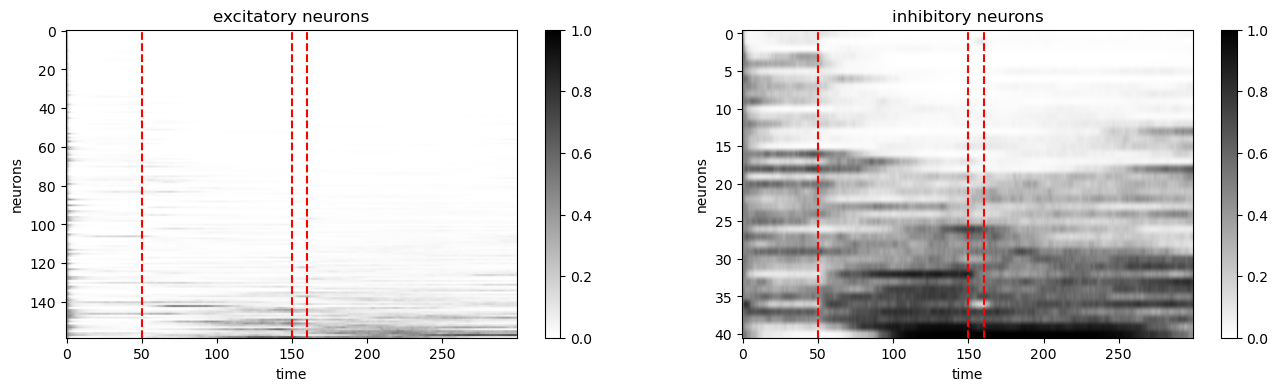

159 excitatory neurons
41 inhibitory neurons


In [12]:
# plot neuron rates

importlib.reload(vu)
vu.plot_neuron_rates(r, exc_ind, inh_ind, 
                     tr_settings['stim_on'], tr_settings['stim_dur'], tr_settings['delay'], sort=1)

#### plot trajectories

In [13]:
from sklearn.decomposition import PCA

In [29]:
# get 100 trials first
importlib.reload(vu)

n_trials = 100
resp_onset = tr_settings['stim_on'] + tr_settings['stim_dur'] + tr_settings['delay']

r_all = np.zeros((n_trials, r.shape[0], r.shape[1]))
labels = np.zeros(n_trials)
perf = np.zeros(n_trials)
for i in range(n_trials):
    if i < int(n_trials/2):
        label = 1
    else:
        label = -1

    u, label = vu.generate_letters_type(tr_settings['T'], tr_settings['stim_on'],
                                        tr_settings['stim_dur'], tr_settings['delay'], label)
    x, r, o = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=tr_settings, u=u)

    if label == 1:
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            perf[i] = 1
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            perf[i] = 1
    
    labels[i] = label
    r_all[i,:,:] = r

print(f'Performance: {np.mean(perf)}')
print(r_all.shape)
print(f'{np.sum(labels ==1)} trials with label 1')
print(f'{np.sum(labels ==-1)} trials with label -1')

Performance: 0.79
(100, 200, 300)
50 trials with label 1
50 trials with label -1


In [30]:
# mean over trials w same labels
r_mean = np.zeros((r.shape[0], r.shape[1], 2)) # trial_type x neuron x time
r_mean[:,:,0] = np.mean(r_all[labels == 1,:,:], axis=0)
r_mean[:,:,1] = np.mean(r_all[labels == -1,:,:], axis=0)
print(r_mean.shape)

# get neuron x trial_type*time from r_mean
r_mean = np.reshape(r_mean, (r_mean.shape[0], -1))
print(r_mean.shape)

# PCA
n_comps = 3
pca = PCA(n_components=n_comps)
pcs = pca.fit_transform(r_mean.T)
print(pcs.shape)

# reshape back to trial_type x neuron x time
pcs = np.reshape(pcs, (-1, 2, n_comps))
print(pcs.shape)

(200, 300, 2)
(200, 600)
(600, 3)
(300, 2, 3)


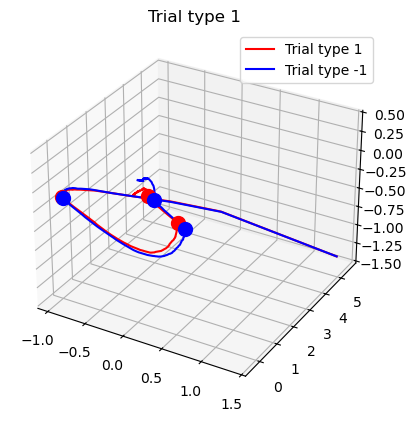

In [31]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[:,i,0], pcs[:,i,1], pcs[:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Trial type {i}')
    ax.legend()
plt.show()

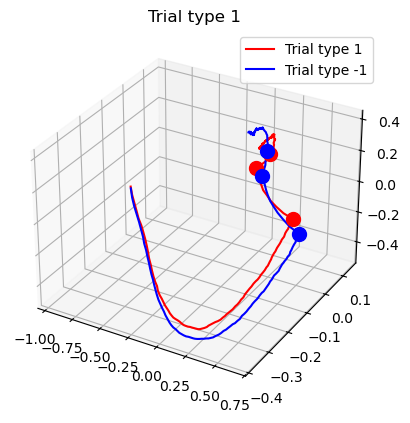

In [32]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'],
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']+10]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[times[0]:,i,0], pcs[times[0]:,i,1], pcs[times[0]:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times[1:]:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Trial type {i}')
    ax.legend()
plt.show()

#### mean over trials that are correct

In [51]:
# mean over trials w same labels and correct only
r_mean = np.zeros((r.shape[0], r.shape[1], 2)) # trial_type x neuron x time
r_mean[:,:,0] = np.mean(r_all[(labels == 1) & (perf == 1),:,:], axis=0)
r_mean[:,:,1] = np.mean(r_all[(labels == -1) & (perf == 1),:,:], axis=0)
print(r_mean.shape)

# vu.plot_neuron_rates(r_mean[:,:,0], exc_ind, inh_ind, 
#                      tr_settings['stim_on'], tr_settings['stim_dur'], tr_settings['delay'], sort=1)

# vu.plot_neuron_rates(r_mean[:,:,1], exc_ind, inh_ind, 
#                      tr_settings['stim_on'], tr_settings['stim_dur'], tr_settings['delay'], sort=1)

# get neuron x trial_type*time from r_mean
r_mean = np.reshape(r_mean, (r_mean.shape[0], -1))
print(r_mean.shape)

# PCA
n_comps = 3
pca = PCA(n_components=n_comps)
pcs = pca.fit_transform(r_mean.T)
print(pcs.shape)

# reshape back to trial_type x neuron x time
pcs = np.reshape(pcs, (-1, 2, n_comps))
print(pcs.shape)

(200, 300, 2)
(200, 600)
(600, 3)
(300, 2, 3)


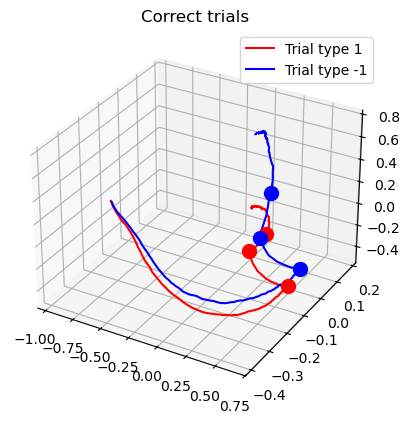

In [44]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'],
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']+10]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[times[0]:,i,0], pcs[times[0]:,i,1], pcs[times[0]:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times[1:]:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Correct trials')
    ax.legend()
plt.show()

#### mean over trials that are incorrect

In [45]:
# mean over trials w same labels and correct only
r_mean = np.zeros((r.shape[0], r.shape[1], 2)) # trial_type x neuron x time
r_mean[:,:,0] = np.mean(r_all[(labels == 1) & (perf == 0),:,:], axis=0)
r_mean[:,:,1] = np.mean(r_all[(labels == -1) & (perf == 0),:,:], axis=0)
print(r_mean.shape)

# get neuron x trial_type*time from r_mean
r_mean = np.reshape(r_mean, (r_mean.shape[0], -1))
print(r_mean.shape)

# PCA
n_comps = 3
pca = PCA(n_components=n_comps)
pcs = pca.fit_transform(r_mean.T)
print(pcs.shape)

# reshape back to trial_type x neuron x time
pcs = np.reshape(pcs, (-1, 2, n_comps))
print(pcs.shape)

(200, 300, 2)
(200, 600)
(600, 3)
(300, 2, 3)


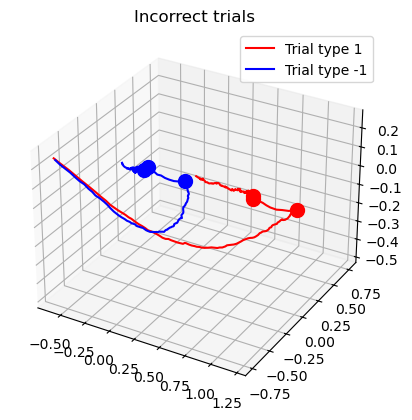

In [46]:
# 3D plot
times = [tr_settings['stim_on'], 
         tr_settings['stim_on']+tr_settings['stim_dur'], 
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay'],
         tr_settings['stim_on']+tr_settings['stim_dur']+tr_settings['delay']+10]
colors = ['r', 'b']
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trial_labels = ['1', '-1']
for i in range(2):
    ax.plot(pcs[times[0]:,i,0], pcs[times[0]:,i,1], pcs[times[0]:,i,2], c=colors[i], label=f'Trial type {trial_labels[i]}')
    for t in times[1:]:
        ax.scatter(pcs[t,i,0], pcs[t,i,1], pcs[t,i,2], c=colors[i], s=100)
    ax.set_title(f'Incorrect trials')
    ax.legend()
plt.show()